<br>
<br>


**Problem Breaks down into five simple steps to solve a problem in monte carlo method:**
- Setting up a probability distribution for important variables.
- Building a cumulative probability distributino for each variable.
- Establishing an interval of random numbers for each variable.
- Generating random numbers.
- Actually simulating a serics of trials.


<br>
<br>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon

print("All libraries imported successfully")

All libraries imported successfully


<br>
<br>

# `#2.1: Irregular Shape:`

<br>
<br>

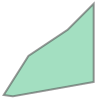

In [2]:

X_Point = []
Y_Point = []

coords = [(1,10),(20,40),(50,60),(70,80),(70,20),(8,9)]
irr_shape = Polygon(coords)
irr_shape 


70
80


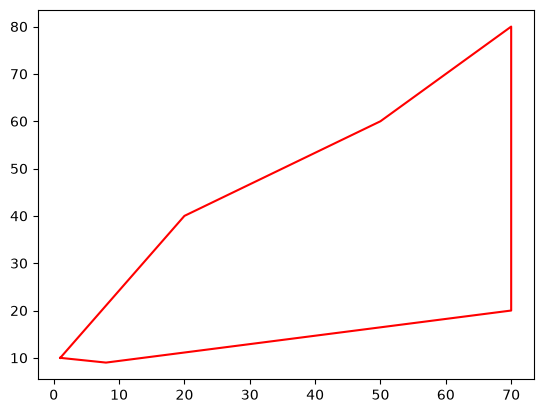

In [3]:

irr_shape_x = [x for x,_ in coords]
irr_shape_y = [y for _,y in coords]

# closing the shape again 
irr_shape_x.append(1)
irr_shape_y.append(10)

print(max(irr_shape_x))
print(max(irr_shape_y))
plt.plot(irr_shape_x,irr_shape_y,c="red")
plt.show()

Actual Area 2409.5
Predicted Area 2520.0000000000005


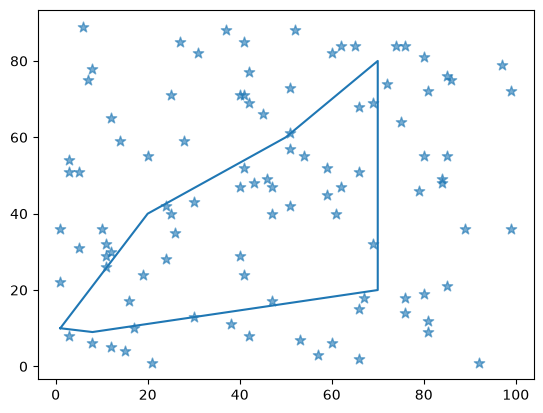

In [4]:

inside = 0 
total = 0 

x = []
y = []

for i in range(100):
    x_corr = np.random.randint(0,100)
    y_corr = np.random.randint(0,90)
    x.append(x_corr)
    y.append(y_corr)
    point = Point(x_corr,y_corr)
    if irr_shape.contains(point):
        inside +=1
    total +=1 

plt.plot(irr_shape_x,irr_shape_y)
plt.scatter(x,y,marker='*',s=60,alpha=0.6)
print("Actual Area", irr_shape.area)
print("Predicted Area", (inside/total)*(100*90))



<br>
<br>

# `#2.2: Coin Toss Gambling Game:`

<br>
<br>

In [5]:

# coin toss:
def coin_toss()->int:
    return np.random.randint(0,2)

def gambling_game(no_of_game:int)->tuple[pd.DataFrame,tuple[int,int]]:
    records = []
    win_count = 0
    lose_count = 0
    for i in range(1,no_of_game+1):
        flips = 0
        head_count = 0
        tail_count = 0
        while(abs(head_count-tail_count))<3:
            flips+=1
            if coin_toss()==0:
                head_count+=1
            else:
                tail_count+=1
        if flips<8:
            win_count+=1
        else: 
            lose_count+=1
        records.append({"Game_no":i,"Head_Count":head_count,"Tail_Count":tail_count,"Result":flips<8})
            
    return pd.DataFrame(records),(win_count,lose_count)

data_frame,count = gambling_game(50)
print("Win,Loss ",count)
data_frame

Win,Loss  (33, 17)


,Game_no,Head_Count,Tail_Count,Result
0,1,3,0,True
1,2,7,4,False
2,3,3,0,True
3,4,7,10,False
4,5,1,4,True
5,6,7,4,False
6,7,5,8,False
7,8,3,0,True
8,9,0,3,True
9,10,0,3,True


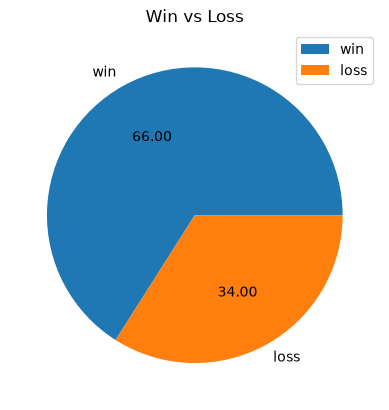

In [6]:


plt.title(f"Win vs Loss")
data_frame["Result"].astype(int).value_counts().rename({0:"loss",1:"win"}).plot(kind="pie",autopct="%.2f")
plt.legend()
plt.show()



<br>
<br>

# `#2.3: Numerical Intregation:`

```txt
- যেকোনো, x_i তে curve-এর height = xi_3
- তার নিচে থাকা সব y value হলো valid area
```
<br>
<br>

In [7]:



# true value: 152.25
def make_eq(x):
    return x**3 


def numerical_intregation(n:int,upper_limit:int,lower_limit:int)->tuple[list,int]:
    val = []
    rec_height = make_eq(upper_limit)
    x  = np.linspace(lower_limit,upper_limit,n)
    y = np.random.random(n)*rec_height
    x_3 = x**3 
    shed_val = 0
    for i in range(n):
        if y[i]<x_3[i]:
            shed_val+=1
        area = (shed_val/(i+1)) * rec_height * (upper_limit-lower_limit)
        val.append(area)
    return area,val

area , val = numerical_intregation(10000,5,2)
print(area)



153.45


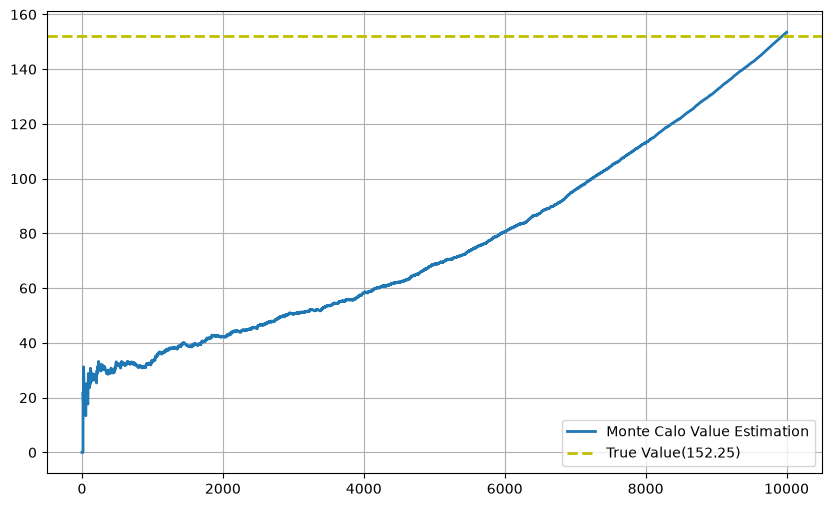

In [8]:

plt.figure(figsize=(10,6))
plt.plot(val,label="Monte Calo Value Estimation",linewidth=2)
plt.axhline(y=152.25,linestyle="--",color="y",label="True Value(152.25)",linewidth=2)
plt.grid()
plt.legend()
plt.show()


<br>
<br>

# `#2.4: Value of pi:`

<br>

```txt
Area of circle = pi*r^2
Area of sqaure = 2r*2r = 4 r*2 

pi*r^2/4r^2 = pi/4 = inside_circle/total 

pi = 4 *(inside_cricle/4)
```

<br>

In [9]:
np.random.random(size=5)

array([0.84307788, 0.72658377, 0.12983257, 0.67351589, 0.43167841])

In [10]:

def value_of_pi(n:int):
    x = np.random.random(size=n)
    y = np.random.random(size=n)
    inside_cnt = 0
    val = []
    for i in range(n):
        if (x[i]**2+y[i]**2)<1:
            inside_cnt +=1 
        value = 4*(inside_cnt/(i+1))
        val.append(value)
    return value,val

value, val = value_of_pi(100000)
value

3.13952

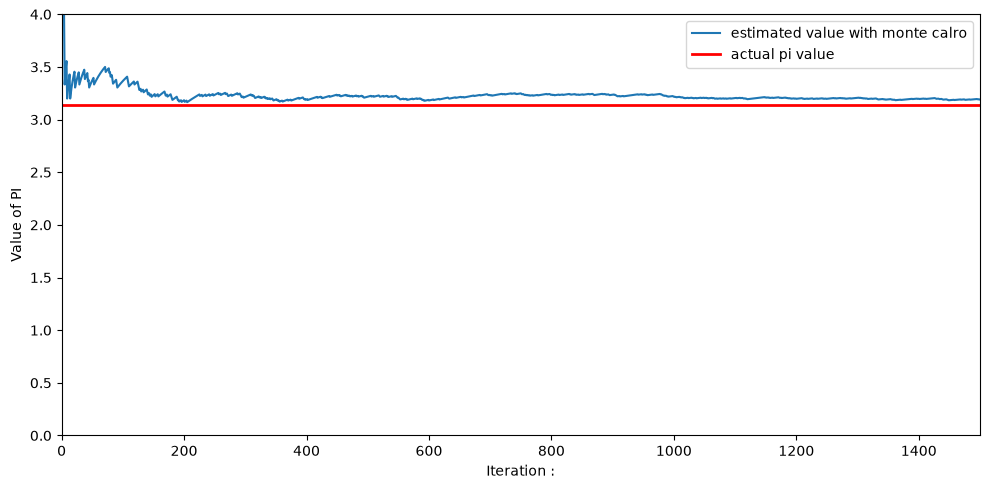

In [11]:

plt.figure(figsize=(10,5))
plt.plot(val,label="estimated value with monte calro")
plt.axhline(y=np.pi,color="red",label="actual pi value",linewidth=2)
plt.xlabel("Iteration :")
plt.ylabel("Value of PI")
plt.ylim(0,4)
plt.xlim(0,1500)
plt.legend()
plt.tight_layout()
plt.show()


<br>
<br>


# `#2.5: A random walk`

<br>
<br>

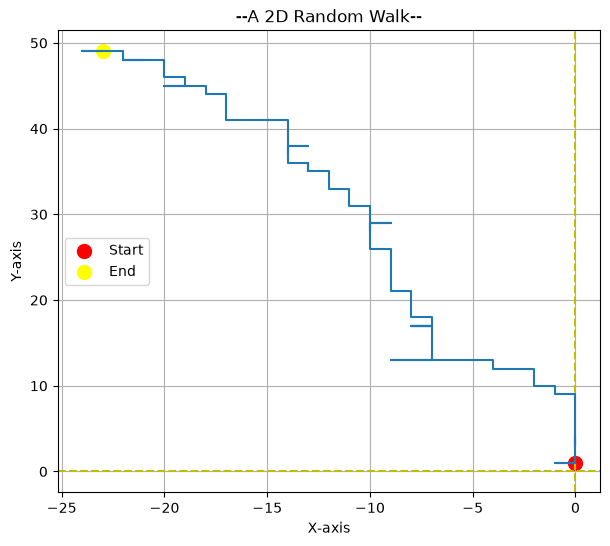

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def a_random_walk(total_step: int):
    expt = []
    x = y = 0

    for _ in range(total_step):
        r_num = np.random.randint(0, 11)

        if r_num in [0, 1, 2, 3, 4]:
            y += 1
        elif r_num in [5, 6, 7]:
            x -= 1
        elif r_num in [8, 9]:
            x += 1
        else:
            y -= 1   # r_num = 10 হলে নিচে যাবে

        expt.append([x, y])

    return np.array(expt)


ans = a_random_walk(100)

plt.figure(figsize=(7, 6))

plt.title("--A 2D Random Walk--")
plt.axhline(y=0, linestyle="--", color="y")
plt.axvline(x=0, linestyle="--", color="y")

plt.plot(ans[:, 0], ans[:, 1])

plt.scatter(ans[0, 0], ans[0, 1], s=100, label="Start", c="red")
plt.scatter(ans[-1, 0], ans[-1, 1], s=100, label="End", c="yellow")

plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.legend()
plt.grid(True)

plt.show()

<br>
<br>

# `#2.6 Reliability Problem:`

<br>
<br>

In [14]:

# ============== dataframe from the question ==============
table_life = {
    "Bearing_Life" : [1000,1100,1200,1300,1400,1500,1600,1700,1800,1900],
    "Probability" : [0.10,0.14,0.24,0.14,0.12,0.10,0.06,0.05,0.03,0.02]
}
bearing_life = pd.DataFrame(table_life)
bearing_life


,Bearing_Life,Probability
0,1000,0.10
1,1100,0.14
2,1200,0.24
3,1300,0.14
4,1400,0.12
5,1500,0.10
6,1600,0.06
7,1700,0.05
8,1800,0.03
9,1900,0.02


In [15]:

# step: 1 determine the Cumulative sum. 
bearing_life["cumsum"] = bearing_life["Probability"].cumsum()
bearing_life

,Bearing_Life,Probability,cumsum
0,1000,0.10,0.10
1,1100,0.14,0.24
2,1200,0.24,0.48
3,1300,0.14,0.62
4,1400,0.12,0.74
5,1500,0.10,0.84
6,1600,0.06,0.90
7,1700,0.05,0.95
8,1800,0.03,0.98
9,1900,0.02,1.00


In [16]:

# Step2: assign random digits:
bearing_life['upper'] = (bearing_life['cumsum']*100).astype(int)
bearing_life

,Bearing_Life,Probability,cumsum,upper
0,1000,0.10,0.10,10
1,1100,0.14,0.24,24
2,1200,0.24,0.48,48
3,1300,0.14,0.62,62
4,1400,0.12,0.74,74
5,1500,0.10,0.84,84
6,1600,0.06,0.90,89
7,1700,0.05,0.95,95
8,1800,0.03,0.98,98
9,1900,0.02,1.00,100


In [17]:
# let's 100 = 0 
bearing_life["lower"] = (bearing_life["upper"].shift(1).fillna(0)+1).astype(int)
bearing_life

,Bearing_Life,Probability,cumsum,upper,lower
0,1000,0.10,0.10,10,1
1,1100,0.14,0.24,24,11
2,1200,0.24,0.48,48,25
3,1300,0.14,0.62,62,49
4,1400,0.12,0.74,74,63
5,1500,0.10,0.84,84,75
6,1600,0.06,0.90,89,85
7,1700,0.05,0.95,95,90
8,1800,0.03,0.98,98,96
9,1900,0.02,1.00,100,99


In [18]:
bearing_life.iloc[-1,3] = 0 
bearing_life

,Bearing_Life,Probability,cumsum,upper,lower
0,1000,0.10,0.10,10,1
1,1100,0.14,0.24,24,11
2,1200,0.24,0.48,48,25
3,1300,0.14,0.62,62,49
4,1400,0.12,0.74,74,63
5,1500,0.10,0.84,84,75
6,1600,0.06,0.90,89,85
7,1700,0.05,0.95,95,90
8,1800,0.03,0.98,98,96
9,1900,0.02,1.00,0,99


In [19]:

# ===== now make the table for delay: ======
delay_data = {
    "delay_time(min)":[4,6,8],
    "probability":[0.3,0.6,0.1]
}

delay  = pd.DataFrame(delay_data)
delay["cumsum"] = delay['probability'].cumsum()
delay['upper'] =(delay['cumsum']*10)
delay['lower'] = delay['upper'].shift(1).fillna(0)+1 
delay.iloc[-1,3] = 0 

# lower = 10: no problem cause upper< in the last case
delay


,delay_time(min),probability,cumsum,upper,lower
0,4,0.3,0.3,3.0,1.0
1,6,0.6,0.9,9.0,4.0
2,8,0.1,1.0,0.0,10.0


In [20]:


# ====== Getting the value of bearing life ==========
def get_bearing_life_val(random_digit,df): 
    for idx,row in df.iterrows():
        low = row['lower']
        high = row['upper']
        if low<= random_digit <= high:
            return row["Bearing_Life"]
        elif high<= random_digit <= low:
            return row["Bearing_Life"]
        
get_bearing_life_val(1,bearing_life)


np.float64(1000.0)

In [21]:


# ====== Getting the value of random digit ==========
def get_delay_val(random_digit,df): 
    for idx,row in df.iterrows():
        low = row['lower']
        high = row['upper']
        if low<= random_digit <= high:
            return row["delay_time(min)"]
        elif high<= random_digit <= low:
            return row["delay_time(min)"]
        
get_delay_val(0,delay)


np.float64(8.0)

In [22]:

# how to make random digit with numpy?
# make random digit from 0 to 9 
np.random.randint(0,10,1)


array([8])

In [23]:

# ======== For the 3 breaing ============
def three_brearing_together_policy(target_hours):
    ans = []
    
    # ===== total 3 bearing seperately =====
    for i in range(3):
        #print("loop -> ", i )
        total_time = 0
        while True:
            random_number_bearing = np.random.randint(0,100,1).item() 
            random_number_delay = np.random.randint(0,10,1).item() 
            life_time = get_bearing_life_val(random_number_bearing,df=bearing_life)
            delay_time = get_delay_val(random_number_delay,df=delay)
            total_time += life_time
            ans.append(
                {   "Bearing_ID":(i+1),
                    "RD_Bearing":random_number_bearing,
                    "Life_Time":life_time,
                    "Cum_Life_Time": total_time,
                    "RD_Delay":random_number_delay,
                    "Delay_time":delay_time
                }
            )
            #print("------------", total_time)
            if total_time>=target_hours:
                break
    return pd.DataFrame(ans)

three_bearing  = three_brearing_together_policy(18000)
three_bearing.sample(5)


,Bearing_ID,RD_Bearing,Life_Time,Cum_Life_Time,RD_Delay,Delay_time
7,1,30,1200.0,10400.0,0,8.0
0,1,51,1300.0,1300.0,4,6.0
17,2,37,1200.0,4800.0,1,4.0
31,3,49,1300.0,3800.0,2,4.0
18,2,38,1200.0,6000.0,0,8.0


In [24]:

# bearing 1 info:
three_bearing[three_bearing["Bearing_ID"]==1].reset_index()

,index,Bearing_ID,RD_Bearing,Life_Time,Cum_Life_Time,RD_Delay,Delay_time
0,0,1,51,1300.0,1300.0,4,6.0
1,1,1,57,1300.0,2600.0,7,6.0
2,2,1,57,1300.0,3900.0,5,6.0
3,3,1,6,1000.0,4900.0,3,4.0
4,4,1,35,1200.0,6100.0,8,6.0
5,5,1,59,1300.0,7400.0,9,6.0
6,6,1,96,1800.0,9200.0,9,6.0
7,7,1,30,1200.0,10400.0,0,8.0
8,8,1,60,1300.0,11700.0,7,6.0
9,9,1,57,1300.0,13000.0,1,4.0


In [25]:

# bearing 2 info:
three_bearing[three_bearing["Bearing_ID"]==2].reset_index()

,index,Bearing_ID,RD_Bearing,Life_Time,Cum_Life_Time,RD_Delay,Delay_time
0,14,2,62,1300.0,1300.0,7,6.0
1,15,2,10,1000.0,2300.0,0,8.0
2,16,2,60,1300.0,3600.0,7,6.0
3,17,2,37,1200.0,4800.0,1,4.0
4,18,2,38,1200.0,6000.0,0,8.0
5,19,2,69,1400.0,7400.0,0,8.0
6,20,2,17,1100.0,8500.0,1,4.0
7,21,2,41,1200.0,9700.0,1,4.0
8,22,2,55,1300.0,11000.0,5,6.0
9,23,2,32,1200.0,12200.0,9,6.0


In [26]:

# bearing -3 info
three_bearing[three_bearing["Bearing_ID"]==3].reset_index()

,index,Bearing_ID,RD_Bearing,Life_Time,Cum_Life_Time,RD_Delay,Delay_time
0,29,3,42,1200.0,1200.0,9,6.0
1,30,3,57,1300.0,2500.0,7,6.0
2,31,3,49,1300.0,3800.0,2,4.0
3,32,3,34,1200.0,5000.0,4,6.0
4,33,3,81,1500.0,6500.0,8,6.0
5,34,3,13,1100.0,7600.0,6,6.0
6,35,3,82,1500.0,9100.0,8,6.0
7,36,3,58,1300.0,10400.0,7,6.0
8,37,3,53,1300.0,11700.0,3,4.0
9,38,3,30,1200.0,12900.0,2,4.0


In [28]:

total_bearing = len(three_bearing)
total_delay  = three_bearing["Delay_time"].sum().item()

# one bearing = 20 
bearnig_cost = total_bearing * 20 
print("Bearing Cost: ",bearnig_cost)


# repairement cost: 25 per hour
repaire_cost = (total_delay/60) * 25 
print("Repaire_cost: ",repaire_cost)

# downtime_cost: 5 per minute 
downltime_cost = (total_delay + (total_bearing*20))* 5 
print("Downtime Cost: ",downltime_cost)


total_cost_when_change_bearing_theree_sep = (bearnig_cost+repaire_cost+downltime_cost)

print("Total cost", total_cost_when_change_bearing_theree_sep)



Bearing Cost:  880
Repaire_cost:  105.83333333333333
Downtime Cost:  5670.0
Total cost 6655.833333333333


In [29]:
np.random.randint(0,10,1).item()

1

In [30]:
three_bearing[three_bearing["Bearing_ID"]==1]["Life_Time"][0]

np.float64(1300.0)

In [31]:

# ======================= Change 3 Bearing at once ======================

def get_value_table(bearing_idx,val_idx):
    try:
        val = three_bearing[three_bearing["Bearing_ID"]==bearing_idx]["Life_Time"].iloc[val_idx]
        return val 
    except:
        random_number = np.random.randint(0,10,1).item() 
        return get_bearing_life_val(random_number,df=bearing_life)
    

def chage_three_bearing_at_once(target_hours):
    cnt = 0 
    all_recoards = []
    total_time = 0 
    while True: 
        
        # ====== get value for bearing ======
        bearing1 = get_value_table(1,cnt)
        bearing2 = get_value_table(2,cnt)
        bearing3 = get_value_table(3,cnt)
        cnt+=1
        
        first_failure = min(bearing1,bearing2,bearing3)
        total_time += first_failure
        
        # ====== get value for time ======
        rd = np.random.randint(0,10,1).item()
        del_time = get_delay_val(rd,df=delay)
        
        all_recoards.append({
            "Bearing1":bearing1,
            "Bearing2":bearing2,
            "Bearing3":bearing3,
            "First_Failure":first_failure,
            "cumsum_lifetime": total_time,
            "RD": rd,
            "delay": del_time 
        })
        
        if total_time>=target_hours:
            break 
    return pd.DataFrame(all_recoards)

change_all = chage_three_bearing_at_once(18000)
change_all

,Bearing1,Bearing2,Bearing3,First_Failure,cumsum_lifetime,RD,delay
0,1300.0,1300.0,1200.0,1200.0,1200.0,9,6.0
1,1300.0,1000.0,1300.0,1000.0,2200.0,6,6.0
2,1300.0,1300.0,1300.0,1300.0,3500.0,2,4.0
3,1000.0,1200.0,1200.0,1000.0,4500.0,5,6.0
4,1200.0,1200.0,1500.0,1200.0,5700.0,6,6.0
5,1300.0,1400.0,1100.0,1100.0,6800.0,1,4.0
6,1800.0,1100.0,1500.0,1100.0,7900.0,7,6.0
7,1200.0,1200.0,1300.0,1200.0,9100.0,3,4.0
8,1300.0,1300.0,1300.0,1300.0,10400.0,9,6.0
9,1300.0,1200.0,1200.0,1200.0,11600.0,3,4.0


In [32]:


total_bearing = len(change_all)
total_delay  = change_all["delay"].sum().item()

# one bearing = 20 
bearnig_cost = total_bearing * 20 
print("Bearing Cost: ",bearnig_cost)


# repairement cost: 25 per hour
repaire_cost = (total_delay/60) * 25 
print("Repaire_cost: ",repaire_cost)

# downtime_cost: 5 per minute 
downltime_cost = (total_delay + (total_bearing*20))* 5 
print("Downtime Cost: ",downltime_cost)


total_cost_replace_3_at_once = (bearnig_cost+repaire_cost+downltime_cost)

print("Total cost", total_cost_replace_3_at_once)



Bearing Cost:  340
Repaire_cost:  36.666666666666664
Downtime Cost:  2140.0
Total cost 2516.6666666666665


In [33]:


print("repalce one by one : ",total_cost_when_change_bearing_theree_sep)
print("repalce_3_at_once : ",total_cost_replace_3_at_once)


repalce one by one :  6655.833333333333
repalce_3_at_once :  2516.6666666666665


<br>
<br>

# `#2.7 Bombing Problem:`

<br>
<br>

In [34]:
np.random.normal(loc=0,scale=1,size=10)

array([-0.1562924 , -1.49252743,  1.50334696, -1.44087739, -1.21153466,
        0.74562961, -0.07169804, -1.41146794, -0.44094946, -0.72456994])

******************** Top 10 Result ********************
        rnn_w       rnn_h result
0 -422.090468  220.664932    win
1 -166.323290  427.166563   loss
2  522.943473   45.848245    win
3   38.788113 -146.742149    win
4 -484.774310   59.609397    win
5  500.741795   -1.271607    win
6 -200.006257 -450.842192   loss
7  795.574972 -346.883990   loss
8 -267.779222  263.357375    win
9  497.920598  272.578016    win
******************** Win vs Lose Count ********************


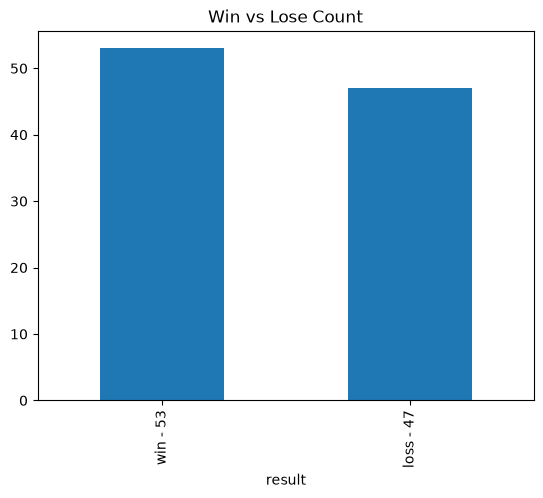

In [35]:

def bombing_prb(n:int,x:int,y:int):
    mu = 0
    std = 1 
    rnn_w = np.random.normal(loc=mu,scale=std,size=n)*x
    rnn_h = np.random.normal(loc=mu,scale=std,size=n)*y 
    result = []
    for i in range(n):
        if (rnn_w[i]>= -x and rnn_h[i]<=x) & (rnn_h[i]>=-y and rnn_h[i]<=y):
            result.append({
                "rnn_w":rnn_w[i],
                "rnn_h":rnn_h[i],
                "result": "win"
            })
        else:
             result.append({
                "rnn_w":rnn_w[i],
                "rnn_h":rnn_h[i],
                "result": "loss"
            })
    return pd.DataFrame(result)

res = bombing_prb(100,x=500,y=300)

print("*"*20,"Top 10 Result","*"*20)
print(res.head(10))
print("*"*20,"Win vs Lose Count","*"*20)
win,loss = res["result"].value_counts()
res["result"].value_counts().plot(kind="bar",title="Win vs Lose Count")
plt.xticks([0,1],labels=[f"win - {win}","loss - {}".format(loss)])
plt.show()